## Emotion Recognition

dataset: emotion recognition data  
https://www.kaggle.com/datasets/jonathanoheix/face-expression-recognition-dataset

using the face expression recognition dataset, i built my own cnn model to improve emotion recognition performance using the concepts learned in class.

in the beginning, the model accuracy was much lower. after trying different model sizes, dropout values, augmentation settings, batch size, learning rate, and training time, the final selected model gave the best validation accuracy among the tested versions.

this notebook shows the full workflow from loading the dataset to training, evaluating, testing, and saving the final model.

### step 1: importing libraries

in this step, i import all the libraries needed for:
- data handling
- visualization
- model building
- training
- evaluation
- saving outputs

In [2]:
# step 1: import required libraries for the full pipeline

import os  # used for working with folders, file paths, and checking whether directories exist
import time  # used to measure training time and epoch time
import random  # used to control randomness for reproducible results
import warnings  # used to hide unnecessary warning messages in the notebook

import numpy as np  # used for numerical operations, arrays, and metric calculations
import pandas as pd  # used for simple table-like data handling such as class distribution summaries
import matplotlib.pyplot as plt  # used for plotting graphs such as accuracy curves and loss curves
import seaborn as sns  # used for cleaner visualizations such as class distribution plots

import torch  # main pytorch library used for tensors, model training, and deep learning operations
import torch.nn as nn  # contains neural network layers like conv2d, linear, dropout, and batchnorm
import torch.optim as optim  # contains optimizers like adam used to update model weights

from torchvision import datasets, transforms  # datasets helps load image folders and transforms helps preprocess images
from torch.utils.data import DataLoader  # used to load data in mini-batches during training and validation

from sklearn.metrics import confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay  # used for evaluation metrics and confusion matrix plotting

warnings.filterwarnings("ignore")  # ignore extra warnings to keep the notebook output cleaner

### step 2: setting the random seed

in this step, i fix the random seed so that the training behavior is more stable and reproducible across runs.

In [3]:
# step 2: fix random seed for reproducibility

seed = 42

torch.manual_seed(seed)      # controls pytorch randomness
np.random.seed(seed)         # controls numpy randomness
random.seed(seed)            # controls python randomness

print("seed set to:", seed)

seed set to: 42


### step 3: checking the device

in this step, i check whether the notebook can use:
- mps for macbook m series
- cuda for nvidia gpu
- cpu if no accelerator is available

this is important because training on the wrong device can make the notebook much slower.

In [4]:
# step 3: select the best available device

if torch.backends.mps.is_available():
    device = torch.device("mps")   # best option for macbook m series
elif torch.cuda.is_available():
    device = torch.device("cuda")  # best option for nvidia gpu
else:
    device = torch.device("cpu")   # fallback option

print("using device:", device)

using device: mps


### step 4: creating folders for outputs

in this step, i create folders to store:
- graphs
- confusion matrix
- saved model file

In [5]:
# step 4: create folders to store outputs and trained model

os.makedirs("./outputs", exist_ok=True)        # folder for graphs and confusion matrix
os.makedirs("./saved_models", exist_ok=True)   # folder for trained model file

print("output folders are ready")

output folders are ready


### step 5: attaching the dataset

in this step, i define the dataset paths.

the dataset is already organized into:
- train
- validation

so i do not need to manually split the data again.

In [6]:
# step 5: define dataset paths

dataset_root = "./emotion_dataset"
train_dir = os.path.join(dataset_root, "train")
val_dir = os.path.join(dataset_root, "validation")

print("train directory:", train_dir)
print("validation directory:", val_dir)
print("train exists:", os.path.exists(train_dir))
print("validation exists:", os.path.exists(val_dir))

train directory: ./emotion_dataset/train
validation directory: ./emotion_dataset/validation
train exists: True
validation exists: True


### step 6: defining image transforms

in this step, i define the preprocessing and augmentation pipeline.

for training:
- grayscale conversion
- small horizontal flip
- small rotation
- small affine shift
- normalization

for validation:
- grayscale conversion
- normalization only

i kept the augmentation light because stronger augmentation reduced performance in some earlier runs.

In [7]:
# step 6: define transforms for training and validation

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # keep the input single channel because the dataset is grayscale
    transforms.RandomHorizontalFlip(p=0.5),       # add variation without changing the class
    transforms.RandomRotation(5),                 # small rotation only, because large rotation hurt performance
    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),                   # small translation to improve generalization
        scale=(0.97, 1.03)                        # small scale change to avoid too much distortion
    ),
    transforms.ToTensor(),                        # convert image to pytorch tensor
    transforms.Normalize(mean=[0.5], std=[0.5])  # normalize grayscale values
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # validation should match the real data format
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

### step 7: loading the dataset

in this step, i load the train and validation dataset using imagefolder.
this automatically reads the folder names as class labels.

In [8]:
# step 7: load datasets using imagefolder

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transform)

print("classes:", train_dataset.classes)
print("number of classes:", len(train_dataset.classes))

classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
number of classes: 7


### step 8: showing dataset size

in this step, i inspect how many images are available in training and validation.
this helps confirm that the dataset was loaded correctly.

In [9]:
# step 8: show dataset size

print("total training images:", len(train_dataset))
print("total validation images:", len(val_dataset))

total training images: 28821
total validation images: 7066


### step 9: visualizing class distribution

in this step, i check how many samples belong to each emotion class.
this is useful because class imbalance can affect training.

In [10]:
# step 9: build class distribution table from training samples

train_labels = [label for _, label in train_dataset.samples]   # collect integer labels from dataset
class_counts = pd.Series(train_labels).value_counts().sort_index()

class_distribution_df = pd.DataFrame({
    "label": train_dataset.classes,
    "count": class_counts.values
})

print(class_distribution_df)

      label  count
0     angry   3993
1   disgust    436
2      fear   4103
3     happy   7164
4   neutral   4982
5       sad   4938
6  surprise   3205


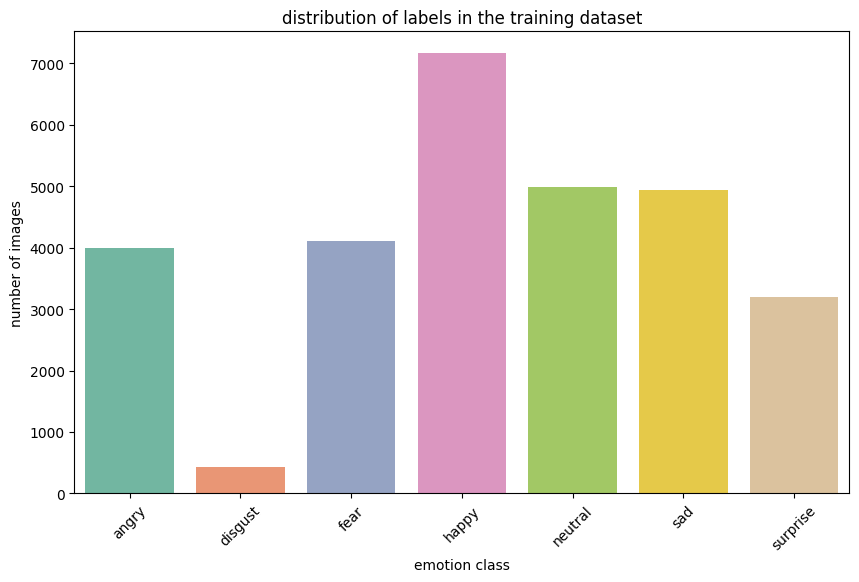

In [11]:
# step 9.1: plot class distribution

plt.figure(figsize=(10, 6))
sns.barplot(x="label", y="count", data=class_distribution_df, palette="Set2")
plt.title("distribution of labels in the training dataset")
plt.xlabel("emotion class")
plt.ylabel("number of images")
plt.xticks(rotation=45)
plt.show()

### step 10: setting dataloader values

in this step, i set:
- batch size
- number of workers
- pin memory
- persistent workers

these values depend on the device.

In [12]:
# step 10: choose dataloader values based on device

if device.type == "mps":
    batch_size = 64
    num_workers = 2
    pin_memory = False
    persistent_workers = True
elif device.type == "cuda":
    batch_size = 64
    num_workers = 4
    pin_memory = True
    persistent_workers = True
else:
    batch_size = 32
    num_workers = 0
    pin_memory = False
    persistent_workers = False

print("batch size:", batch_size)
print("num workers:", num_workers)
print("pin memory:", pin_memory)
print("persistent workers:", persistent_workers)

batch size: 64
num workers: 2
pin memory: False
persistent workers: True


### step 11: creating dataloaders

in this step, i convert the datasets into dataloaders so that the model can read them in mini-batches during training and validation.

In [13]:
# step 11: create train and validation dataloaders

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,                                      # shuffle training data to avoid learning fixed order
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers if num_workers > 0 else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,                                     # keep validation order fixed
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers if num_workers > 0 else False
)

print("train batches:", len(train_loader))
print("validation batches:", len(val_loader))

train batches: 451
validation batches: 111


### step 12: checking batch shape

before training, i check the image and label shapes to make sure they match the expected cnn input format.

In [14]:
# step 12: inspect one batch shape

images, labels = next(iter(train_loader))

print("batch image shape:", images.shape)   # expected shape is [batch, 1, 48, 48]
print("batch label shape:", labels.shape)

batch image shape: torch.Size([64, 1, 48, 48])
batch label shape: torch.Size([64])


### step 13: visualizing sample images

in this step, i display a few images from the training set to make sure the input pipeline is working correctly.

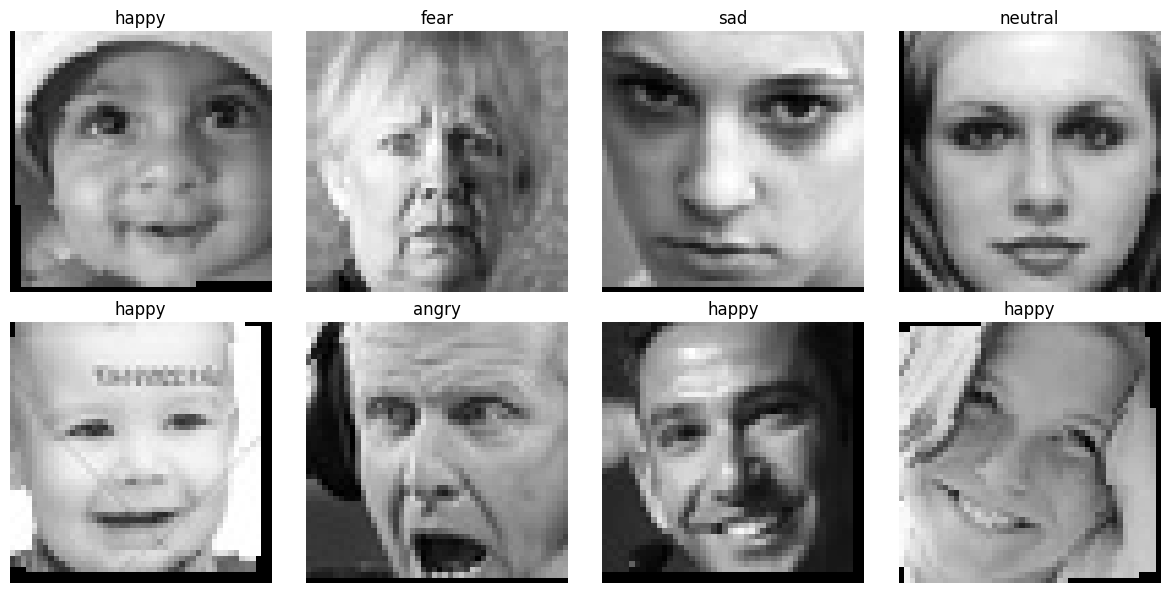

In [15]:
# step 13: visualize some sample training images

class_names = train_dataset.classes
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    image = images[i].squeeze().cpu().numpy()
    image = (image * 0.5) + 0.5         # undo normalization for display
    plt.imshow(image, cmap="gray")
    plt.title(class_names[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

### step 14: split explanation

this dataset is already split into train and validation folders, so i do not use random split here.

the split values are directly controlled by the dataset structure.

In [16]:
# step 14: print split explanation clearly

print("training folder path:", train_dir)
print("validation folder path:", val_dir)
print("manual split is not needed because the dataset already provides train and validation folders")

training folder path: ./emotion_dataset/train
validation folder path: ./emotion_dataset/validation
manual split is not needed because the dataset already provides train and validation folders


### step 15: defining the cnn model

in the beginning, i tried simpler models, but they gave low validation accuracy.

after many experiments, the final selected model became a vgg-style cnn with:
- 4 convolution blocks
- batch normalization
- max pooling
- dropout
- fully connected classifier

this version gave the best validation result among all tested versions.

In [17]:
# step 15: define the final vgg style cnn model

class VGGEmotionCNN(nn.Module):
    def __init__(self, num_classes):
        super(VGGEmotionCNN, self).__init__()

        self.features = nn.Sequential(
            # block 1
            nn.Conv2d(1, 64, kernel_size=3, padding=1, bias=False),  # first feature extractor
            nn.BatchNorm2d(64),                                      # batch norm makes training more stable
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),                   # reduce spatial size from 48 to 24
            nn.Dropout(0.10),                                        # light dropout in early block

            # block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),                   # reduce spatial size from 24 to 12
            nn.Dropout(0.15),

            # block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),                   # reduce spatial size from 12 to 6
            nn.Dropout(0.20),

            # block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),                   # reduce spatial size from 6 to 3
            nn.Dropout(0.25)
        )

        self.classifier = nn.Sequential(
            nn.Linear(512 * 3 * 3, 512),                             # flatten features into dense layer
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),

            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20),

            nn.Linear(128, num_classes)                              # final output layer for 7 classes
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)   # flatten starting from dimension 1 and keep batch dimension unchanged
        x = self.classifier(x)
        return x

num_classes = len(train_dataset.classes)
model = VGGEmotionCNN(num_classes=num_classes).to(device)

print(model)

VGGEmotionCNN(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.1, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): Ma

## model improvement story

the first model versions were weaker and validation accuracy was much lower.

some runs suffered from:
- underfitting
- overfitting
- too much augmentation
- too much dropout
- unstable learning rate settings

to improve the performance, i changed:
- model depth
- dropout values
- augmentation strength
- batch size
- learning rate
- scheduler patience
- total number of epochs

the final selected model was not the one with the highest training accuracy only, but the one that gave the best validation accuracy.

### step 16: defining loss, optimizer, and scheduler

in this step, i define:
- cross entropy loss for multi-class classification
- adam optimizer
- reduce on plateau scheduler

these settings gave the best balance between learning and generalization.

In [18]:
# step 16: define training components

criterion = nn.CrossEntropyLoss()   # standard loss for multi-class classification

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0007,                      # tuned learning rate that worked better than larger or smaller values
    weight_decay=5e-5               # small weight decay helps regularization
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",                     # monitor validation accuracy, so higher is better
    factor=0.5,                     # reduce lr by half when validation performance stalls
    patience=4
)

print("loss, optimizer, and scheduler are ready")

loss, optimizer, and scheduler are ready


### step 17: training setup

in this step, i define the main training variables and the best-model saving path.

the notebook saves the best model whenever validation accuracy improves.

In [19]:
# step 17: define training settings

num_epochs = 50

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0
best_epoch = 0
epochs_without_improvement = 0
patience = 10

best_model_path = "./saved_models/emotion_model.pth"

print("num epochs:", num_epochs)
print("patience:", patience)
print("best model path:", best_model_path)

num epochs: 50
patience: 10
best model path: ./saved_models/emotion_model.pth


## training experience

training this model took many trials.

some models were too weak and stayed in the 50 percent range. some stronger models gave high training accuracy but lower validation accuracy, which showed overfitting.

i had to try different:
- dropout strengths
- augmentation levels
- batch sizes
- number of epochs
- learning rate values

the final selected run was the one that achieved the best validation accuracy around 70.22 percent.

In [20]:
# step 18: train the model and validate it after each epoch
# save the model whenever validation accuracy improves

start_total_time = time.time()

for epoch in range(num_epochs):
    epoch_start_time = time.time()

    # training phase
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=(device.type == "cuda"))
        labels = labels.to(device, non_blocking=(device.type == "cuda"))

        optimizer.zero_grad(set_to_none=True)  # set gradients to none for slightly better efficiency

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()                        # backpropagation
        optimizer.step()                       # update model weights

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)  # choose class with highest output score
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_accuracy = 100.0 * correct_train / total_train

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    # validation phase
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():                     # disable gradients during validation to save memory and time
        for images, labels in val_loader:
            images = images.to(device, non_blocking=(device.type == "cuda"))
            labels = labels.to(device, non_blocking=(device.type == "cuda"))

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_accuracy = 100.0 * correct_val / total_val

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    scheduler.step(epoch_val_accuracy)        # update learning rate when validation accuracy stops improving

    if epoch_val_accuracy > best_val_accuracy:
        best_val_accuracy = epoch_val_accuracy
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_model_path)  # save the best model only
    else:
        epochs_without_improvement += 1

    current_lr = optimizer.param_groups[0]["lr"]
    epoch_time = time.time() - epoch_start_time

    print(f"epoch [{epoch+1}/{num_epochs}] "
          f"lr: {current_lr:.6f} | "
          f"train loss: {epoch_train_loss:.4f}, train acc: {epoch_train_accuracy:.2f}% | "
          f"val loss: {epoch_val_loss:.4f}, val acc: {epoch_val_accuracy:.2f}% | "
          f"time: {epoch_time:.2f}s")

    if epochs_without_improvement >= patience:
        print(f"early stopping triggered at epoch {epoch+1}")
        break

total_time = time.time() - start_total_time
print(f"\ntotal training time: {total_time / 60:.2f} minutes")

epoch [1/50] lr: 0.000700 | train loss: 1.7337, train acc: 28.75% | val loss: 1.7001, val acc: 35.89% | time: 51.25s
epoch [2/50] lr: 0.000700 | train loss: 1.4469, train acc: 44.09% | val loss: 1.3190, val acc: 50.11% | time: 45.77s
epoch [3/50] lr: 0.000700 | train loss: 1.3228, train acc: 49.39% | val loss: 1.3076, val acc: 50.55% | time: 45.73s
epoch [4/50] lr: 0.000700 | train loss: 1.2611, train acc: 51.96% | val loss: 1.2229, val acc: 53.16% | time: 46.33s
epoch [5/50] lr: 0.000700 | train loss: 1.2153, train acc: 54.10% | val loss: 1.1285, val acc: 56.41% | time: 48.15s
epoch [6/50] lr: 0.000700 | train loss: 1.1817, train acc: 55.33% | val loss: 1.1352, val acc: 56.98% | time: 50.50s
epoch [7/50] lr: 0.000700 | train loss: 1.1481, train acc: 56.70% | val loss: 1.1516, val acc: 55.76% | time: 53.95s
epoch [8/50] lr: 0.000700 | train loss: 1.1254, train acc: 57.58% | val loss: 1.0695, val acc: 59.02% | time: 47.46s
epoch [9/50] lr: 0.000700 | train loss: 1.0985, train acc: 58.51

### step 19: showing prediction images

after training, i load the best saved model and show some predictions from the validation set.
this helps visually inspect whether the model predictions make sense.

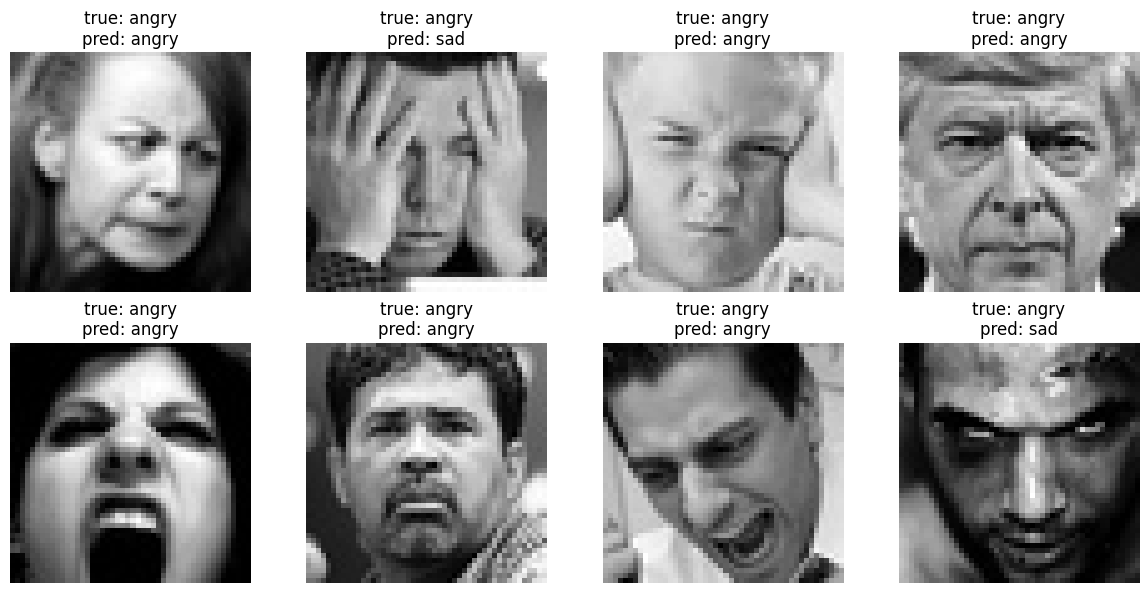

In [21]:
# step 19: load best model and display sample predictions

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

images, labels = next(iter(val_loader))

with torch.no_grad():
    outputs = model(images.to(device))
    _, predicted = torch.max(outputs, 1)

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    image = images[i].squeeze().cpu().numpy()
    image = (image * 0.5) + 0.5
    plt.imshow(image, cmap="gray")
    plt.title(f"true: {class_names[labels[i].item()]}\npred: {class_names[predicted[i].item()]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### step 20: confusion graph

in this step, i run the saved best model on the full validation set and create the confusion matrix.

In [22]:
# step 20: collect predictions for full validation set

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device, non_blocking=(device.type == "cuda"))
        labels = labels.to(device, non_blocking=(device.type == "cuda"))

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

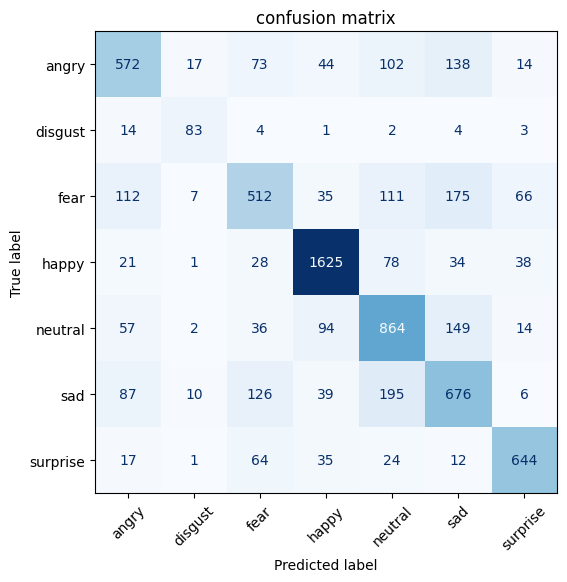

In [23]:
# step 20.1: plot confusion matrix

cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", xticks_rotation=45, ax=ax, colorbar=False)
plt.title("confusion matrix")
plt.savefig("./outputs/confusion_matrix.png")
plt.show()

### step 21: accuracy, f1 score, and report

in this step, i compute:
- final validation accuracy
- weighted f1 score
- classification report

In [24]:
# step 21: compute final evaluation metrics

final_accuracy = 100.0 * np.mean(np.array(all_labels) == np.array(all_predictions))
weighted_f1 = f1_score(all_labels, all_predictions, average="weighted")

print(f"best validation accuracy: {best_val_accuracy:.2f}%")
print(f"best epoch: {best_epoch}")
print(f"final validation accuracy: {final_accuracy:.2f}%")
print(f"weighted f1 score: {weighted_f1:.4f}")

print("\nclassification report:")
print(classification_report(all_labels, all_predictions, target_names=train_dataset.classes))

best validation accuracy: 70.42%
best epoch: 50
final validation accuracy: 70.42%
weighted f1 score: 0.7022

classification report:
              precision    recall  f1-score   support

       angry       0.65      0.60      0.62       960
     disgust       0.69      0.75      0.72       111
        fear       0.61      0.50      0.55      1018
       happy       0.87      0.89      0.88      1825
     neutral       0.63      0.71      0.67      1216
         sad       0.57      0.59      0.58      1139
    surprise       0.82      0.81      0.81       797

    accuracy                           0.70      7066
   macro avg       0.69      0.69      0.69      7066
weighted avg       0.70      0.70      0.70      7066



### step 22: tuning summary

in this step, i summarize the tuning values that gave the final selected model.

In [25]:
# step 22: print tuning summary

print("final optimizer: adam")
print("learning rate: 0.0007")
print("weight decay: 5e-5")
print("scheduler: reducelronplateau")
print("batch size:", batch_size)
print("best epoch:", best_epoch)
print("best validation accuracy:", f"{best_val_accuracy:.2f}%")

final optimizer: adam
learning rate: 0.0007
weight decay: 5e-5
scheduler: reducelronplateau
batch size: 64
best epoch: 50
best validation accuracy: 70.42%


### step 23: matrix + accuracy summary

this step gives a simple final summary of the main results.

In [26]:
# step 23: print final summary values

print("final summary")
print("---------------------")
print(f"training images: {len(train_dataset)}")
print(f"validation images: {len(val_dataset)}")
print(f"number of classes: {len(train_dataset.classes)}")
print(f"best validation accuracy: {best_val_accuracy:.2f}%")
print(f"best epoch: {best_epoch}")
print(f"weighted f1 score: {weighted_f1:.4f}")

final summary
---------------------
training images: 28821
validation images: 7066
number of classes: 7
best validation accuracy: 70.42%
best epoch: 50
weighted f1 score: 0.7022


### step 24: visualization of training curves

in this step, i plot the training and validation curves for:
- accuracy
- loss

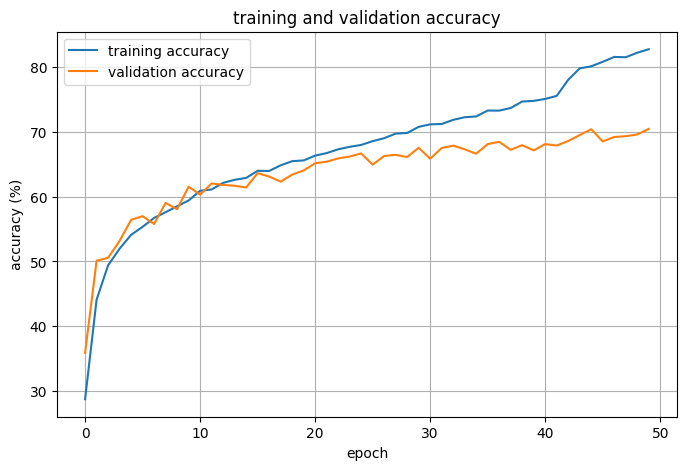

In [27]:
# step 24: plot and save training vs validation accuracy

plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="training accuracy")
plt.plot(val_accuracies, label="validation accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy (%)")
plt.title("training and validation accuracy")
plt.legend()
plt.grid(True)
plt.savefig("./outputs/accuracy_curve.png")
plt.show()

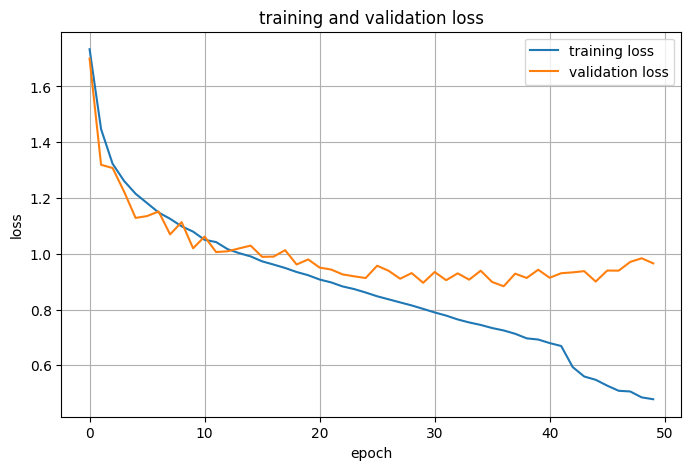

In [28]:
# step 24.1: plot and save training vs validation loss

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="training loss")
plt.plot(val_losses, label="validation loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("training and validation loss")
plt.legend()
plt.grid(True)
plt.savefig("./outputs/loss_curve.png")
plt.show()

### step 25: testing

in this step, i load the saved model file and test it again using the validation loader.
this confirms that the saved model works properly outside the training loop.

In [29]:
# step 25: test the saved model again

model.load_state_dict(torch.load("./saved_models/emotion_model.pth", map_location=device))
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"test accuracy using saved model: {test_accuracy:.2f}%")

test accuracy using saved model: 70.42%


### step 26: saving the model

in pytorch, the standard way to save the trained model weights is by using a `.pth` file.

In [30]:
# step 26: save the final trained model

torch.save(model.state_dict(), "./saved_models/emotion_model.pth")
print("model saved successfully at ./saved_models/emotion_model.pth")

model saved successfully at ./saved_models/emotion_model.pth


## final conclusion

in this notebook, i built a cnn model for facial emotion recognition using pytorch.

i started with simpler models, but they did not give enough validation accuracy. after many experiments with model depth, dropout, augmentation, batch size, learning rate, and training duration, i selected the final vgg-style cnn as the best model.

the final notebook includes:
- dataset loading
- class distribution
- image visualization
- cnn model definition
- training and validation
- confusion matrix
- accuracy and loss curves
- f1 score and classification report
- testing using the saved model
- saved pytorch model file